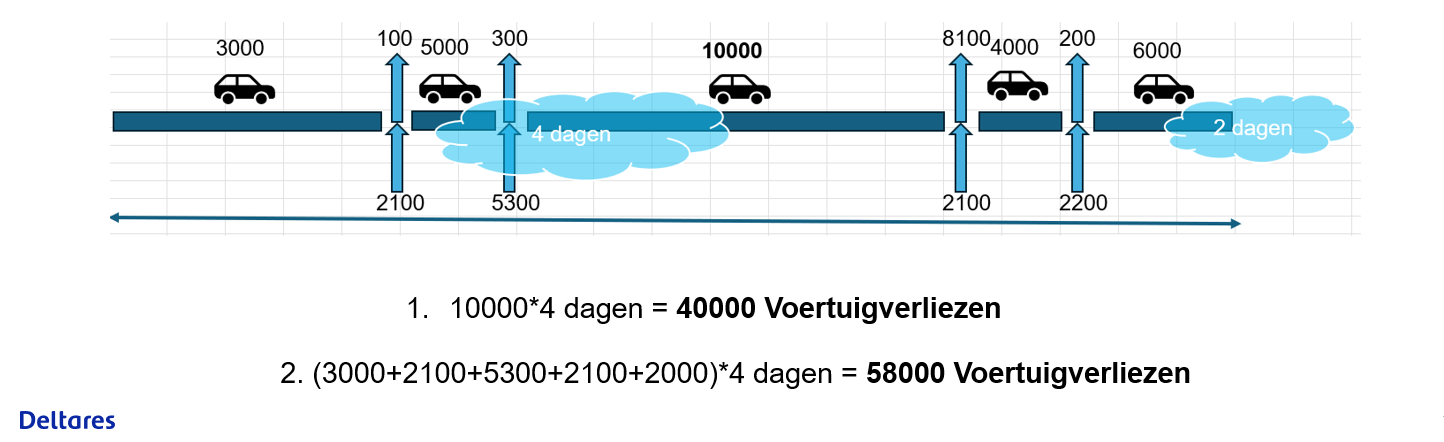

In [1]:
from pathlib import Path
import geopandas as gpd

In [2]:
region_list = ["ARK-NZK","Vallei en Veluwe",
               "Achterhoek", "Brabantse Delta","Friesland",
               "Groningen en NO-Drenthe","Limburg",
               "Noord-Brabant Oost","Noord-Westelijke Delta",
               "Rivierenland","Scheldestromen","Zuiderzeeland",
               "Overijsselse Vecht"
               ]

In [3]:
#Linking traffic data road segments
import pandas as pd
root_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Traffic_Analysis_Data")
root_dir.mkdir(parents=True, exist_ok=True)
data = Path(r"P:\bovenregionale-stresstest-hwn\Data\Traffic_data\INWEVA_2024 (1)")
traffic_geometry_path=data.joinpath("INWEVA_2024_netwerk\INWEVA_2024_netwerk.shp") 
werkdag_traffic_csv_path = data.joinpath("inweva_werkdag_2024DEC.csv")
traffic_geometry= gpd.read_file(traffic_geometry_path, driver='SHP') 
traffic= pd.read_csv(werkdag_traffic_csv_path, sep=';') 

traffic_subset = traffic[['VBN_ID', 'AL_E_WR', 'VRPC_E_WR', "L1_E_WR","L2_E_WR","L3_E_WR"]]
traffic_subset['VBN_ID'] = traffic_subset['VBN_ID'].astype(str)
result = traffic_geometry.merge(traffic_subset, left_on='vbn_id', right_on='VBN_ID', how='left')
print(f"Original traffic_geometry rows: {len(traffic_geometry)}")
print(f"Result rows: {len(result)}")
print(result.columns.tolist())

# Save the result as a geopackage
# Rename the VBN_ID column to avoid conflicts
result_renamed = result.rename(columns={'VBN_ID': 'traffic_vbn_id'})

output_path = root_dir.joinpath("traffic_werkdag_2024DEC_etmaalintensiteiten.gpkg")
if output_path.exists():  # overwrite existing file
    output_path.unlink()
result_renamed.to_file(output_path, driver='GPKG')
print(f"Saved merged data to: {output_path}")
#print(f"Saved merged data to: {output_path}")

result_renamed = result.drop(columns=['VBN_ID'])# Rename the VBN_ID column to avoid conflicts
result_exploded = result_renamed.copy()# Split nwb_ids and create duplicate rows for each value
result_exploded['nwb_ids'] = result_exploded['nwb_ids'].str.split(', ')# Split the nwb_ids column by comma and expand into separate rows
result_exploded = result_exploded.explode('nwb_ids')
result_exploded = result_exploded.reset_index(drop=True)# Reset index after exploding
result_exploded['individual_nwb_id'] = result_exploded['nwb_ids']# Create a new column with individual nwb_id values
#print(f"Original rows: {len(result_renamed)}")
#print(f"Exploded rows: {len(result_exploded)}")


### check here!!!
# Select only the required columns from traffic and create a proper copy
#AL_E_WR = Totale INWEVA intensiteit over periode 'dag' 
#VRPC_E_WR = Vrachtpercentage dag werkdag, Freight percentage day working day
traffic_subset_ver01 = result_exploded[['individual_nwb_id', 'AL_E_WR', 'VRPC_E_WR', "L1_E_WR","L2_E_WR","L3_E_WR"]].copy() 
# Convert both columns to string to ensure they match
traffic_subset_ver01['individual_nwb_id'] = traffic_subset_ver01['individual_nwb_id'].astype(str)

C:\Users\gunaratn\AppData\Local\Temp\ipykernel_25556\4025688485.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic_subset['VBN_ID'] = traffic_subset['VBN_ID'].astype(str)


Original traffic_geometry rows: 9049
Result rows: 9049
['vbn_id', 'vbn_oms_tx', 'vbn_oms_bp', 'vbn_lengte', 'regio_cntr', 'regio_alt', 'nwb_ids', 'wegnrhmp_b', 'wegnrhmp_e', 'bpszijde_b', 'bpszijde_e', 'hectoltr_b', 'hectoltr_e', 'bnsubsrt_b', 'bnsubsrt_e', 'km_b', 'km_e', 'hm_midden', 'vbn_id_tgn', 'vias_baan', 'geometry', 'VBN_ID', 'AL_E_WR', 'VRPC_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR']
Saved merged data to: P:\bovenregionale-stresstest-hwn\Analysis\Traffic_Analysis_Data\traffic_werkdag_2024DEC_etmaalintensiteiten.gpkg


In [9]:
traffic_subset_ver01

,individual_nwb_id,AL_E_WR,VRPC_E_WR,L1_E_WR,L2_E_WR,L3_E_WR
0,600093734,3086.0,6.0,2896.0,178.0,12.0
1,600952176,3086.0,6.0,2896.0,178.0,12.0
2,600952177,3086.0,6.0,2896.0,178.0,12.0
3,63174015,2396.0,10.0,2153.0,195.0,47.0
4,600943943,2396.0,10.0,2153.0,195.0,47.0
...,...,...,...,...,...,...
16219,601258923,2890.0,7.0,2688.0,173.0,29.0
16220,601258927,2890.0,7.0,2688.0,173.0,29.0
16221,601265555,2706.0,4.0,2602.0,85.0,19.0
16222,601269269,930.0,35.0,605.0,186.0,140.0


# Calculate vehicle loss hours per wegvak

BE AWARE: there are duplicates. But this is no problem because after this code block we take the maximum value that occurs as the schakel value

In [ ]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

# List of regions to process
region_list = [
    "ARK-NZK", "Vallei en Veluwe", "Achterhoek", "Brabantse Delta", "Friesland",
    "Groningen en NO-Drenthe", "Limburg", "Noord-Brabant Oost", "Noord-Westelijke Delta",
    "Rivierenland", "Scheldestromen", "Zuiderzeeland", "Overijsselse Vecht"
]

all_roads = []

# Load data for each region
for region in region_list:
    road_path = Path(rf"P:\bovenregionale-stresstest-hwn\Analysis\{region}\Outputs\Damages_Filtering_all_columns.gpkg")
    if not road_path.exists():
        print(f"File not found for region {region}: {road_path}. Skipping.")
        continue

    road = gpd.read_file(road_path, driver='GPKG')
    road['region'] = region  # Keep track of region
    all_roads.append(road)

# Stop if no data found
if not all_roads:
    print("No region data found.")
    exit()

# Combine all regions into one GeoDataFrame
combined_roads = gpd.GeoDataFrame(pd.concat(all_roads, ignore_index=True), crs=all_roads[0].crs)

# Normalize WVK_ID
combined_roads['WVK_ID'] = combined_roads['WVK_ID'].astype(str).str.replace('.0', '', regex=False).str.strip()

# Sort and keep row with highest F_EV1_me per WVK_ID + geometry
combined_roads.sort_values(['WVK_ID', 'geometry', 'F_EV1_me'], ascending=[True, True, False], inplace=True)
combined_roads = combined_roads.groupby(['WVK_ID', 'geometry'], as_index=False).first()

# Ensure GeoDataFrame for dissolve
road_copy = gpd.GeoDataFrame(combined_roads.copy(), geometry='geometry', crs="EPSG:28992")

# Identify EV columns
fev1_cols = [c for c in road_copy.columns if c.startswith('F_EV1')]
fev2_cols = [c for c in road_copy.columns if c.startswith('F_EV2')]


 #gdf.loc[(gdf['OR_me_10_fr_25'] == 1) | (gdf['Asset'] == 1) | (gdf['tunnel_percentage'].fillna(0) >= 10), 'remove'] += 1
 #gdf.loc[(gdf['bridge_percentage'].fillna(0) >= 10) | (gdf['viaduct_percentage'].fillna(0) >= 10), 'Asset'] += 1

# Apply removal logic

# This is because flooding of these segments is not considered in the analysis
if 'remove' in road_copy.columns and (road_copy['remove'] == 1).any(): 
    mask_remove = road_copy['remove'] == 1
    if fev1_cols:
        road_copy.loc[mask_remove, fev1_cols] = 0
    if fev2_cols:
        road_copy.loc[mask_remove, fev2_cols] = 0
    print(f"Set F_EV1* and F_EV2* to 0 for {mask_remove.sum()} rows where remove == 1")

#fLOODING IS DISRUPTIVE ONLY IF F_EV1_me > 0.1
# Apply threshold logic for F_EV1_me
if 'F_EV1_me' in road_copy.columns and fev2_cols:
    mask_low = road_copy['F_EV1_me'] < 0.1
    if mask_low.any():
        road_copy.loc[mask_low, fev2_cols] = 0
        print(f"Set F_EV2* to 0 for {mask_low.sum()} rows where F_EV1_me < 0.1")

# Build aggregation dictionary
agg_dict = {}
for col in road_copy.columns:
    if col in ['geometry', 'WVK_ID']:
        continue
    if col in ['F_EV2_ma', 'F_EV1_me', 'F_EV1_ma']:
        agg_dict[col] = 'max'
    elif road_copy[col].dtype.kind in 'biufc':  # numeric columns
        agg_dict[col] = 'max'
    else:
        agg_dict[col] = 'first'

# Dissolve by WVK_ID
road_agg = road_copy.dissolve(by='WVK_ID', aggfunc=agg_dict).reset_index()

# Normalize WVK_ID again
road_agg['WVK_ID'] = road_agg['WVK_ID'].astype(str).str.replace('.0', '', regex=False).str.strip()

# Merge with traffic data
merged = road_agg.merge(traffic_subset_ver01, left_on='WVK_ID', right_on='individual_nwb_id', how='left')

# Ensure traffic columns exist and are numeric
traffic_columns = ['AL_E_WR', 'VRPC_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR']
for col in traffic_columns:
    if col in merged.columns:
        merged[col] = pd.to_numeric(merged[col], errors='coerce').fillna(0)
    else:
        merged[col] = 0

'''
# Calculate loss hours for those segments that are actually affected 
# Ensure F_EV2_ma exists
if 'F_EV2_ma' not in merged.columns:
    merged['F_EV2_ma'] = 0


# Compute voertuigverliesuren (VHLH)
for col in traffic_columns:
    if col == 'VRPC_E_WR':
        merged[col] = merged[col].round(0)
    else:
        merged[f'VHLH_{col}'] = ((merged[col] / 24) * merged['F_EV2_ma']).round(0)

# Initialize all relevant columns with zero
merged['getroffen_vracht_L2+L3_E_WR_perdag'] = 0
merged['getroffen_personen_perdag'] = 0
merged['vracht_op_schakel_totaal'] = 0
merged['personen_op_schakel_totaal'] = 0

# Apply logic based on the value of F_EV1_me
condition = merged['F_EV1_me'] > 0.1 #This should be mean!!

# For rows where F_EV1_ma > 0.1
merged.loc[condition, 'getroffen_vracht_L2+L3_E_WR_perdag'] = merged['L2_E_WR'] + merged['L3_E_WR']
merged.loc[condition, 'getroffen_personen_perdag'] = merged['L1_E_WR'] * 1.117 # amount of people in a car

# For rows where F_EV1_ma <= 0.1
merged.loc[~condition, 'vracht_op_schakel_totaal'] = merged['L2_E_WR'] + merged['L3_E_WR']
merged.loc[~condition, 'personen_op_schakel_totaal'] = merged['L1_E_WR'] * 1.117 # amount of people in a car

'''

# Save result
output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
out_path = output_dir / "Traffic_Analysis_Country_Lieke_check2.gpkg"
if out_path.exists():
    out_path.unlink()
merged.to_file(out_path, driver='GPKG')
print(f"Saved combined country-scale road and traffic data to: {out_path}")

Set F_EV1* and F_EV2* to 0 for 86149 rows where remove == 1
Set F_EV2* to 0 for 86149 rows where F_EV1_me < 0.1


NameError: name 'traffic_subset_ver01' is not defined

### Liekes simple losses code: First based in left right, then aggregated to whole schakels

In [5]:
# Load the traffic data
HWN_traffic_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Traffic_Analysis_Country_Lieke_check2.gpkg")
HWN_traffic = gpd.read_file(HWN_traffic_path, driver='GPKG')

Netwerkschakels_L_R_path = Path(r"P:\bovenregionale-stresstest-hwn\Data\Shapes netwerkschakels\HWN_Netwerkschakels_dissolved_left_right.gpkg")
Netwerkschakels_L_R = gpd.read_file(Netwerkschakels_L_R_path, driver='GPKG')


# Find the maximum VHLH per schakel

by using the maximum value that occurs on that schakel as the representative value for that schakel - left right

In [9]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

# Load Netwerkschakels geometries
Netwerkschakels_L_R_path = Path(r"P:\bovenregionale-stresstest-hwn\Data\Shapes netwerkschakels\HWN_Netwerkschakels_dissolved_left_right.gpkg")
Netwerkschakels_L_R = gpd.read_file(Netwerkschakels_L_R_path, driver='GPKG')

# Normalize HECTO_LTTR_NWB
HWN_traffic['HECTO_LTTR_NWB'] = HWN_traffic['HECTO_LTTR_NWB'].astype(str).str.lower().str.strip()

# Keep ramps (do not filter out a–d)
filtered_traffic = HWN_traffic.copy()

# ✅ Apply filter: only consider rows where F_EV1_me > 0.1
filtered_traffic = filtered_traffic[filtered_traffic['F_EV1_me'] > 0.1].copy()

# Sort by schakel and VHLH descending
#filtered_traffic.sort_values(['NETWERKSCH_HWN', 'VHLH_AL_E_WR'], ascending=[True, False], inplace=True)
filtered_traffic.sort_values(['NETWERKSCH_HWN', 'AL_E_WR'], ascending=[True, False], inplace=True) # sort by AL_E_WR instead of VHLH

# Take first row per schakel (highest VHLH among rows with F_EV1_me > 0.1)
max_rows = filtered_traffic.groupby('NETWERKSCH_HWN', as_index=False).first()

# Select relevant columns (including F_EV2_ma as duration)
selected_rows = max_rows[['NETWERKSCH_HWN', 
                          #'VHLH_AL_E_WR', 'VHLH_L1_E_WR', 'VHLH_L2_E_WR', 'VHLH_L3_E_WR',
                          'F_EV2_ma', 'F_EV1_me', 'VRPC_E_WR', 'AL_E_WR',
                          'L1_E_WR', 'L2_E_WR', 'L3_E_WR'
                        # "getroffen_personen_perdag", "getroffen_vracht_L2+L3_E_WR_perdag", 'vracht_op_schakel_totaal', "personen_op_schakel_totaal"
                        ]].copy()

# Merge geometries from Netwerkschakels_L_R
selected = selected_rows.merge(Netwerkschakels_L_R[['NETWERKSCH', 'geometry']],
                                left_on='NETWERKSCH_HWN', right_on='NETWERKSCH', how='left')
selected.drop(columns=['NETWERKSCH'], inplace=True)

display(selected.head())

# calculating vehicle loss hours (VHLH) 

# Ensure traffic columns exist and are numeric
traffic_columns = ['AL_E_WR', 'VRPC_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR']
for col in traffic_columns:
    if col in selected.columns:
        selected[col] = pd.to_numeric(selected[col], errors='coerce').fillna(0)
    else:
        selected[col] = 0


# Calculate loss hours for those segments that are actually affected 
# Ensure F_EV2_ma exists
if 'F_EV2_ma' not in selected.columns:
    selected['F_EV2_ma'] = 0

# Apply logic based on the value of F_EV1_me
#condition = selected['F_EV1_me'] > 0.1 #This should be mean!!

# Compute voertuigverliesuren (VHLH)
for col in traffic_columns:
    if col == 'VRPC_E_WR':
        selected[col] = selected[col].round(0)
    else:
        selected[f'VHLH_{col}'] = (selected[col] / 24 * 24).round(0) # per hour for the first day

# Initialize all relevant columns with zero
selected['getroffen_vracht_L2+L3_E_WR_perdag'] = 0
selected['getroffen_personen_perdag'] = 0
selected['vracht_op_schakel_totaal'] = 0
selected['personen_op_schakel_totaal'] = 0

# Apply logic based on the value of F_EV1_me
condition = selected['F_EV1_me'] > 0.1 #This should be mean!!

# For rows where F_EV1_ma > 0.1
selected.loc[condition, 'getroffen_vracht_L2+L3_E_WR_perdag'] = selected['L2_E_WR'] + selected['L3_E_WR']
selected.loc[condition, 'getroffen_personen_perdag'] = selected['L1_E_WR'] * 1.117 # amount of people in a car

# For rows where F_EV1_ma <= 0.1
selected.loc[~condition, 'vracht_op_schakel_totaal'] = selected['L2_E_WR'] + selected['L3_E_WR']
selected.loc[~condition, 'personen_op_schakel_totaal'] = selected['L1_E_WR'] * 1.117 # amount of people in a car




# Calculate Value of Time (VOT) per schakel
selected['VOT_L1_gemiddeld'] = selected['VHLH_L1_E_WR'] * 10.42 
selected['VOT_L2L3_gemiddeld'] = (selected['VHLH_L2_E_WR'] + selected['VHLH_L3_E_WR']) * 63.10
selected['VOT_total'] = selected['VOT_L2L3_gemiddeld'] + selected['VOT_L1_gemiddeld']





# Set RD projection (EPSG:28992)
selected = gpd.GeoDataFrame(selected, geometry='geometry', crs="EPSG:28992")

# Define output path
output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
out_path = output_dir / "Simple_Losses_Analysis_Schakel_level_filtered_LR_traffic_max_ver02.gpkg"

# Save to GeoPackage
selected.to_file(out_path, driver='GPKG')

print(f"Saved schakel-level data with attributes and geometries to: {out_path}")

,NETWERKSCH_HWN,F_EV2_ma,F_EV1_me,VRPC_E_WR,AL_E_WR,L1_E_WR,L2_E_WR,L3_E_WR,geometry
0,001-0010-L,698.000000,0.433030,13.0,5003.0,4342.0,386.0,275.0,"MULTILINESTRING ((126204.216 485012.181, 12619..."
1,001-0010-R,698.000000,0.984717,14.0,6628.0,5700.0,540.0,388.0,"MULTILINESTRING ((125797.100 484382.556, 12581..."
2,001-0030-R,52.000000,0.108333,10.0,3629.0,3264.0,274.0,92.0,"MULTILINESTRING ((138038.997 479775.621, 13826..."
3,001-0040-L,0.000000,0.111482,11.0,55826.0,49917.0,3365.0,2545.0,"MULTILINESTRING ((147012.818 470648.987, 14697..."
4,001-0040-R,41.279778,0.114624,11.0,64305.0,56933.0,4286.0,3086.0,"MULTILINESTRING ((144357.822 472056.636, 14441..."


C:\Users\gunaratn\AppData\Local\Temp\ipykernel_33376\1444881016.py:76: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  selected.loc[condition, 'getroffen_vracht_L2+L3_E_WR_perdag'] = selected['L2_E_WR'] + selected['L3_E_WR']


Saved schakel-level data with attributes and geometries to: P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Simple_Losses_Analysis_Schakel_level_filtered_LR_traffic_max_ver02.gpkg


# Per schakel instead of LR distinction

Take the max per netwerkschakelcode instead of LR distinction!

In [ ]:
# -----------------------------
netwerkschakels_path = Path(r"P:\bovenregionale-stresstest-hwn\Data\Shapes netwerkschakels\HWN_schakels_dissolved_NWSCODE2.gpkg")
netwerkschakels = gpd.read_file(netwerkschakels_path, driver='GPKG')

netwerkindeling_path = Path(r"P:\bovenregionale-stresstest-hwn\Data\Shapes netwerkschakels\Shapes netwerkschakels\HWN_netwerkindeling.shp")
netwerkindeling = gpd.read_file(netwerkindeling_path, driver='Esri Shapefile')

simple_losses_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Simple_Losses_Analysis_Schakel_level_filtered_LR_traffic_max_ver02.gpkg")
simple_losses = gpd.read_file(simple_losses_path, driver='GPKG')

In [10]:
import geopandas as gpd
from pathlib import Path

# -----------------------------
# 1. Load input data
# -----------------------------
netwerkschakels_path = Path(r"P:\bovenregionale-stresstest-hwn\Data\Shapes netwerkschakels\HWN_schakels_dissolved_NWSCODE2.gpkg")
netwerkschakels = gpd.read_file(netwerkschakels_path, driver='GPKG')

netwerkindeling_path = Path(r"P:\bovenregionale-stresstest-hwn\Data\Shapes netwerkschakels\Shapes netwerkschakels\HWN_netwerkindeling.shp")
netwerkindeling = gpd.read_file(netwerkindeling_path, driver='Esri Shapefile')

simple_losses_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Simple_Losses_Analysis_Schakel_level_filtered_LR_traffic_max_ver02.gpkg")
simple_losses = gpd.read_file(simple_losses_path, driver='GPKG')

# -----------------------------
# 2. Normalize keys
# -----------------------------
netwerkindeling['NETWERKSCH'] = netwerkindeling['NETWERKSCH'].astype(str).str.strip()
netwerkindeling['NWSCODE'] = netwerkindeling['NWSCODE'].astype(str).str.strip()
simple_losses['NETWERKSCH_HWN'] = simple_losses['NETWERKSCH_HWN'].astype(str).str.strip()
netwerkschakels['NWSCODE'] = netwerkschakels['NWSCODE'].astype(str).str.strip()

# -----------------------------
# 3. Create unique mapping NETWERKSCH -> NWSCODE
# -----------------------------
mapping = netwerkindeling[['NETWERKSCH', 'NWSCODE']].drop_duplicates(subset='NETWERKSCH')

# Check for duplicates in mapping
if mapping['NETWERKSCH'].duplicated().any():
    print("⚠ Warning: Duplicate NETWERKSCH in mapping!")

# -----------------------------
# 4. Join simple_losses with mapping
# -----------------------------
losses_with_code = simple_losses.drop(columns='geometry').merge(
    mapping,
    left_on='NETWERKSCH_HWN',
    right_on='NETWERKSCH',
    how='left'
)

# Check row counts
print(f"Rows before join: {len(simple_losses)}, after join: {len(losses_with_code)}")

# -----------------------------
# 5. Select numeric columns for aggregation
# -----------------------------
loss_columns = [col for col in losses_with_code.columns if col not in ['NETWERKSCH_HWN', 'NETWERKSCH', 'NWSCODE'] and losses_with_code[col].dtype != 'object']

# Remove VRPC_E_WR if present
if 'VRPC_E_WR' in loss_columns:
    loss_columns.remove('VRPC_E_WR')

# -----------------------------
# 6. Define aggregation rules
# -----------------------------
agg_dict = {col: 'sum' for col in loss_columns}
for col in ['F_EV1_me', 'F_EV2_ma']:
    if col in agg_dict:
        agg_dict[col] = 'max'

# -----------------------------
# 7. Aggregate by NWSCODE
# -----------------------------
agg_result = losses_with_code.groupby('NWSCODE', as_index=False).agg(agg_dict)

# -----------------------------
# 8. Merge aggregated data back to NWSCODE geometries
# -----------------------------
result = netwerkschakels.merge(agg_result, on='NWSCODE', how='left')

# Ensure GeoDataFrame
result = gpd.GeoDataFrame(result, geometry='geometry', crs=netwerkschakels.crs)

# -----------------------------
# 9. Save result
# -----------------------------
output_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\aggregated_loss_per_nws_code_traffic_max_ver02.gpkg")
result.to_file(output_path, driver='GPKG')

print(f"✅ Aggregation complete. File saved to: {output_path}")

Rows before join: 256, after join: 256
✅ Aggregation complete. File saved to: P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\aggregated_loss_per_nws_code_traffic_max_ver02.gpkg


# Calculations per region!

In [16]:
# Load schakels with attributes and geometries
schakels_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Simple_Losses_Analysis_Schakel_level_filtered_LR.gpkg")
schakels = gpd.read_file(schakels_path)

regions_path = Path(r"P:\bovenregionale-stresstest-hwn\Data\Hazard_maps\Areas.gpkg")
regions = gpd.read_file(regions_path, driver='GPKG')

## Schakels were joined to the region with the most overlap

In [17]:
import geopandas as gpd

# Ensure both layers use the same CRS
schakels = schakels.to_crs("EPSG:28992")
regions = regions.to_crs("EPSG:28992")

# Spatial join: match schakels and regions that intersect
joined = gpd.sjoin(schakels, regions[['name', 'geometry']], how='inner', predicate='intersects')

# Reset index so schakel index becomes a column
joined = joined.reset_index()  # 'index' now refers to schakel index

# Compute intersection area for each schakel-region pair
joined['intersection_area'] = joined.apply(
    lambda row: row['geometry'].intersection(regions.loc[row['index_right'], 'geometry']).area,
    axis=1
)

# Sort by schakel and intersection area descending
joined.sort_values(['index', 'intersection_area'], ascending=[True, False], inplace=True)

# Keep only the region with the largest overlap per schakel
schakels_with_region = joined.groupby('index', as_index=False).first()

# Drop unnecessary columns
schakels_with_region = schakels_with_region.drop(columns=['index_right', 'intersection_area'])

# Merge back with original schakels to retain geometry and attributes
schakels_with_region = schakels.merge(
    schakels_with_region[['index', 'name']], 
    left_index=True, right_on='index', how='left'
)

# Manually assign region name to specific schakels
schakels_with_region.loc[
    schakels_with_region['NETWERKSCH_HWN'].isin(['012-0020-R', '012-0020-L']),
    'name'
] = 'Noord-Westelijke Delta'

In [18]:
schakels_with_region.to_file(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\schakels_with_region.gpkg", driver='GPKG')

CPLE_AppDefinedError: b"sqlite3_exec(UPDATE gpkg_contents SET min_x = 26744.54030000045, min_y = 307279.8260000012, max_x = 278021.4070999994, max_y = 606213.6999999992 WHERE lower(table_name) = lower('schakels_with_region') AND Lower(data_type) = 'features') failed: unable to open database file"

Exception ignored in: 'fiona._shim.gdal_flush_cache'
Traceback (most recent call last):
  File "fiona\_err.pyx", line 201, in fiona._err.GDALErrCtxManager.__exit__
fiona._err.CPLE_AppDefinedError: b"sqlite3_exec(UPDATE gpkg_contents SET min_x = 26744.54030000045, min_y = 307279.8260000012, max_x = 278021.4070999994, max_y = 606213.6999999992 WHERE lower(table_name) = lower('schakels_with_region') AND Lower(data_type) = 'features') failed: unable to open database file"


In [19]:
# Create mask for schakels with VHLH_AL_E_WR > 0
mask_vhlh_positive = schakels_with_region['VHLH_AL_E_WR'] > 0

# Aggregate relevant columns per region (sum)
agg_columns = [
    'VHLH_AL_E_WR', 'VHLH_L1_E_WR', 'VHLH_L2_E_WR', 'VHLH_L3_E_WR',
    "AL_E_WR", 'VOT_L1_gemiddeld', 'VOT_L2L3_gemiddeld', "VOT_total",
    "getroffen_personen_perdag", 'getroffen_vracht_L2+L3_E_WR_perdag'
]

region_loss_summary = (
    schakels_with_region[mask_vhlh_positive]
    .groupby('name')[agg_columns]
    .sum()
    .reset_index()
    .round(0)
)

#Compute average duration per region
avg_duration = (
    schakels_with_region[mask_vhlh_positive]
    .groupby('name')['F_EV2_ma']
    .mean()
    .reset_index()
    .rename(columns={'F_EV2_ma': 'avg_F_EV2_ma'})
    .round(2)
)


# Merge into summary
region_loss_summary = region_loss_summary.merge(avg_duration, on='name', how='left')

#Keep as GeoDataFrame by joining region geometries
region_loss_summary = regions[['name', 'geometry']].merge(region_loss_summary, on='name', how='left')
region_loss_summary = gpd.GeoDataFrame(region_loss_summary, geometry='geometry', crs="EPSG:28992")

# Drop geometry column and export to Excel
region_loss_summary_no_geom = region_loss_summary.drop(columns=['geometry'])
region_loss_summary_no_geom.to_excel(output_dir / "Region_Loss_Summary_filtered.xlsx", index=False)

In [20]:
region_loss_summary

,name,geometry,VHLH_AL_E_WR,VHLH_L1_E_WR,VHLH_L2_E_WR,VHLH_L3_E_WR,AL_E_WR,VOT_L1_gemiddeld,VOT_L2L3_gemiddeld,VOT_total,getroffen_personen_perdag,getroffen_vracht_L2+L3_E_WR_perdag,avg_F_EV2_ma
0,Zuiderzeeland,"MULTIPOLYGON Z (((177148.808 539475.219 0.000,...",335039.0,294925.0,22825.0,17287.0,35173.0,3073118.0,2531067.0,5604186.0,34648.0,4154,209.99
1,Noord-Westelijke Delta,"MULTIPOLYGON Z (((102132.491 433603.397 0.000,...",7739643.0,6896732.0,417442.0,425487.0,947509.0,71863947.0,53188820.0,125052767.0,937946.0,107810,160.36
2,Scheldestromen,"MULTIPOLYGON Z (((50218.626 418893.688 0.000, ...",502411.0,444171.0,35140.0,23096.0,149816.0,4628262.0,3674692.0,8302953.0,145536.0,19522,88.06
3,Noord-Brabant Oost,"MULTIPOLYGON Z (((165500.048 425300.017 0.000,...",12262745.0,10055727.0,1117906.0,1089180.0,1138458.0,104780675.0,139267127.0,244047802.0,1039723.0,207647,256.69
4,Brabantse Delta,"MULTIPOLYGON Z (((135355.278 409851.854 0.000,...",6096731.0,4894712.0,553095.0,648960.0,661273.0,51002899.0,75849670.0,126852570.0,590935.0,132237,202.29
5,ARK-NZK,"MULTIPOLYGON Z (((142790.507 467590.764 0.000,...",32936640.0,29103556.0,2084874.0,1748238.0,1453456.0,303259054.0,241869367.0,545128421.0,1428470.0,174614,455.97
6,Rivierenland,"MULTIPOLYGON Z (((135367.704 446111.962 0.000,...",2070946.0,1634772.0,173943.0,262244.0,245825.0,17034324.0,27523400.0,44557724.0,216860.0,51681,210.02
7,Overijsselse Vecht,"MULTIPOLYGON Z (((230144.507 560167.131 0.000,...",6736990.0,5492517.0,648293.0,596212.0,464248.0,57232027.0,78528266.0,135760293.0,424174.0,84506,343.12
8,Achterhoek,"MULTIPOLYGON Z (((188340.955 443260.219 0.000,...",1948345.0,1561690.0,193938.0,192726.0,330537.0,16272810.0,24398498.0,40671308.0,295726.0,65789,174.35
9,Limburg,"MULTIPOLYGON Z (((191781.700 414459.772 0.000,...",1546856.0,1208358.0,154358.0,184132.0,773428.0,12591090.0,21358719.0,33949809.0,674868.0,169245,48.00


# COMPLEX OLD

In [ ]:
# #Traffic complex

# import numpy as np

# # Losses for schakel
# HWN_traffic_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Traffic_Analysis_Country.gpkg")
# HWN_traffic = gpd.read_file(HWN_traffic_path, driver='GPKG')

# # Normalize HECTO_LTTR_NWB and create mask for excluded letters a,b,c,d (case-insensitive)
# HWN_traffic['HECTO_LTTR_NWB'] = HWN_traffic.get('HECTO_LTTR_NWB', '').astype(str).str.lower().str.strip()
# exclude_letters = {'a', 'b', 'c', 'd'}
# mask_exclude = HWN_traffic['HECTO_LTTR_NWB'].isin(exclude_letters)

# # Create filtered columns that are None for excluded HECTO_LTTR_NWB rows
# HWN_traffic['traffic_Al_E_WR_filtered'] = HWN_traffic['traffic_Al_E_WR'].where(~mask_exclude, None)
# HWN_traffic['F_EV2_ma_filtered'] = HWN_traffic.get('F_EV2_ma', 0).where(~mask_exclude, None)

# # Dissolve HWN_traffic by NETWERKSCH_HWN, aggregate traffic/F_EV2 as lists (both original and filtered)
# dissolved = HWN_traffic.dissolve(
#     by='NETWERKSCH_HWN',
#     aggfunc={
#         'traffic_Al_E_WR': list,              # all values
#         'F_EV2_ma': list,                     # all values
#         'traffic_Al_E_WR_filtered': list,     # filtered (excludes rows with HECTO_LTTR_NWB in a,b,c,d)
#         'F_EV2_ma_filtered': list             # filtered
#     }
# ).reset_index()

# # Utility to get max while ignoring None/NaN
# def max_ignore_none(lst):
#     if not isinstance(lst, list):
#         return None
#     clean = [i for i in lst if pd.notnull(i)]
#     return max(clean) if clean else None

# # Add s_traffic_Al_E_WR using the filtered list (so excluded letters are ignored)
# dissolved['s_traffic_Al_E_WR'] = dissolved['traffic_Al_E_WR_filtered'].apply(max_ignore_none)

# # Add max_F_EV2_ma using the filtered list
# dissolved['max_F_EV2_ma'] = dissolved['F_EV2_ma_filtered'].apply(max_ignore_none)

# # Optionally rename list columns for clarity (keep both original-list and filtered-list names)
# dissolved.rename(columns={
#     'traffic_Al_E_WR': 'traffic_Al_E_WR_list',
#     'F_EV2_ma': 'F_EV2_ma_list',
#     'traffic_Al_E_WR_filtered': 'traffic_Al_E_WR_filtered_list',
#     'F_EV2_ma_filtered': 'F_EV2_ma_filtered_list'
# }, inplace=True)

# # Convert lists to comma-separated strings before saving (for all list columns)
# for col in ['traffic_Al_E_WR_list', 'F_EV2_ma_list', 'traffic_Al_E_WR_filtered_list', 'F_EV2_ma_filtered_list']:
#     if col in dissolved.columns:
#         dissolved[col] = dissolved[col].apply(lambda x: ",".join([str(i) for i in x]) if isinstance(x, list) else "")

# # Compute simple losses (will be NaN if either is None; change to 0 if you prefer)
# dissolved['simple_losses'] = dissolved['s_traffic_Al_E_WR'] * dissolved['max_F_EV2_ma']

# # --- Add first and last traffic_Al_E_WR for each schakel, ignoring a/b/c/d ---

# # Filter out excluded letters
# filtered = HWN_traffic[~mask_exclude].copy()

# # Helper to get geometry start x/y
# def get_start_xy(geom):
#     if geom is None or geom.is_empty:
#         return (np.inf, np.inf)
#     if geom.geom_type == 'LineString':
#         return geom.coords[0]
#     elif geom.geom_type == 'MultiLineString':
#         # Use the first LineString's first point
#         return list(geom.geoms)[0].coords[0]
#     else:
#         return (np.inf, np.inf)

# filtered['start_x'] = filtered.geometry.apply(lambda g: get_start_xy(g)[0])
# filtered['start_y'] = filtered.geometry.apply(lambda g: get_start_xy(g)[1])

# # Sort by schakel and start_x/start_y
# filtered_sorted = filtered.sort_values(['NETWERKSCH_HWN', 'start_x', 'start_y'])

# # Get first and last traffic_Al_E_WR per NETWERKSCH_HWN
# first_traffic = filtered_sorted.groupby('NETWERKSCH_HWN').first().reset_index()
# last_traffic = filtered_sorted.groupby('NETWERKSCH_HWN').last().reset_index()

# first_map = dict(zip(first_traffic['NETWERKSCH_HWN'], first_traffic['traffic_Al_E_WR']))
# last_map = dict(zip(last_traffic['NETWERKSCH_HWN'], last_traffic['traffic_Al_E_WR']))

# dissolved['first_traffic_Al_E_WR'] = dissolved['NETWERKSCH_HWN'].map(first_map)
# dissolved['last_traffic_Al_E_WR'] = dissolved['NETWERKSCH_HWN'].map(last_map)
# # --- Add OPR_traffic_sum and OPR_values columns ---

# opr_mask = HWN_traffic['BST_CODE_NWB'].astype(str).str.upper().str.strip() == 'OPR'
# opr_grouped = (
#     HWN_traffic[opr_mask]
#     .groupby('NETWERKSCH_HWN')['traffic_Al_E_WR']
#     .agg([
#         ('OPR_traffic_sum', 'sum'),
#         ('OPR_values', lambda x: ",".join([str(i) for i in x]))
#     ])
#     .reset_index()
# )
# dissolved = dissolved.merge(opr_grouped, on='NETWERKSCH_HWN', how='left')

# dissolved['complex_losses_first'] = (dissolved['first_traffic_Al_E_WR']+dissolved['OPR_traffic_sum']) * dissolved['max_F_EV2_ma']
# dissolved['complex_losses_last'] = (dissolved['last_traffic_Al_E_WR']+dissolved['OPR_traffic_sum']) * dissolved['max_F_EV2_ma']

# output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
# out_path = output_dir.joinpath("Complex_Losses_Analysis_Schakel_level.gpkg")
# dissolved.to_file(out_path, driver="GPKG")

CPLE_AppDefinedError: b"sqlite3_exec(UPDATE gpkg_contents SET last_change = strftime('%Y-%m-%dT%H:%M:%fZ','now') WHERE lower(table_name) = lower('Complex_Losses_Analysis_Schakel_level')) failed: disk I/O error"

Exception ignored in: 'fiona._shim.gdal_flush_cache'
Traceback (most recent call last):
  File "fiona\_err.pyx", line 201, in fiona._err.GDALErrCtxManager.__exit__
fiona._err.CPLE_AppDefinedError: b"sqlite3_exec(UPDATE gpkg_contents SET last_change = strftime('%Y-%m-%dT%H:%M:%fZ','now') WHERE lower(table_name) = lower('Complex_Losses_Analysis_Schakel_level')) failed: disk I/O error"
